# EpiLink: Epidemiological Linkage Inference

EpiLink scores the compatibility of a pair of pathogen samples with recent transmission scenarios using:
- **Temporal distance**: The difference in sampling dates (in days).
- **Genetic distance**: The number of mutations between consensus genomic sequences.

This notebook demonstrates how to configure the model, score observed pairs, and use the built-in simulation engine.

In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns

from epilink import (
    EpiLink, 
    InfectiousnessToTransmission, 
    NaturalHistoryParameters,
    simulate_epidemic_dates, 
    simulate_genomic_sequences, 
    build_pairwise_case_table
)

# Set plot style
sns.set_theme(style="white", context="paper", font_scale=1.5)

## 1. Natural History Parameters

The `NaturalHistoryParameters` class defines the underlying E/P/I (Latent/Presymptomatic/Syptomatic) model. You can use the defaults (based on SARS-CoV-2 literature) or provide custom values.

In [2]:
params = NaturalHistoryParameters(
    incubation_shape=5.8,
    incubation_scale=0.95,
    latent_shape=3.4,
    substitution_rate=0.001,  # sub/site/year
    genome_length=29903,  # for converting substitution_rate to sub/genome/day
)

print(f"Presymptomatic shape: {params.presymptomatic_shape:.2f}")
print(f"Infectiousness normalisation: {params.infectiousness_normalisation:.3f}")
print(f"Presymptomatic transmission fraction: {params.presymptomatic_transmission_fraction:.2%}")

Presymptomatic shape: 2.40
Infectiousness normalisation: 0.126
Presymptomatic transmission fraction: 65.89%


## 2. Model Initialization

We wrap the parameters in a `InfectiousnessToTransmission` profile, which handles the stochastic sampling of intervals, and then initialize the `EpiLink` model.

In [3]:
profile = InfectiousnessToTransmission(parameters=params, rng_seed=2026)

model = EpiLink(
    transmission_profile=profile,
    maximum_depth=2,  # Hidden intermediates/branch depths up to 2
    mc_samples=20000, # Monte Carlo draws per scenario
    target=["ad(0)", "ca(0,0)"], # Subset for the combined score
    mutation_process="stochastic"
)

print(f"Enumerated {len(model.scenarios)} scenarios:")

for s in model.scenarios:
    print(f"\t{s}")

Enumerated 9 scenarios:
	ad(0)
	ad(1)
	ad(2)
	ca(0,0)
	ca(0,1)
	ca(0,2)
	ca(1,0)
	ca(1,1)
	ca(2,0)


## 3. Visualizing Scenario Distributions

EpiLink precomputes distributions of sampling-time differences ($T_s$) and branch lengths ($B_s$) for each scenario. We can inspect these to understand how the model distinguishes between transmission histories.

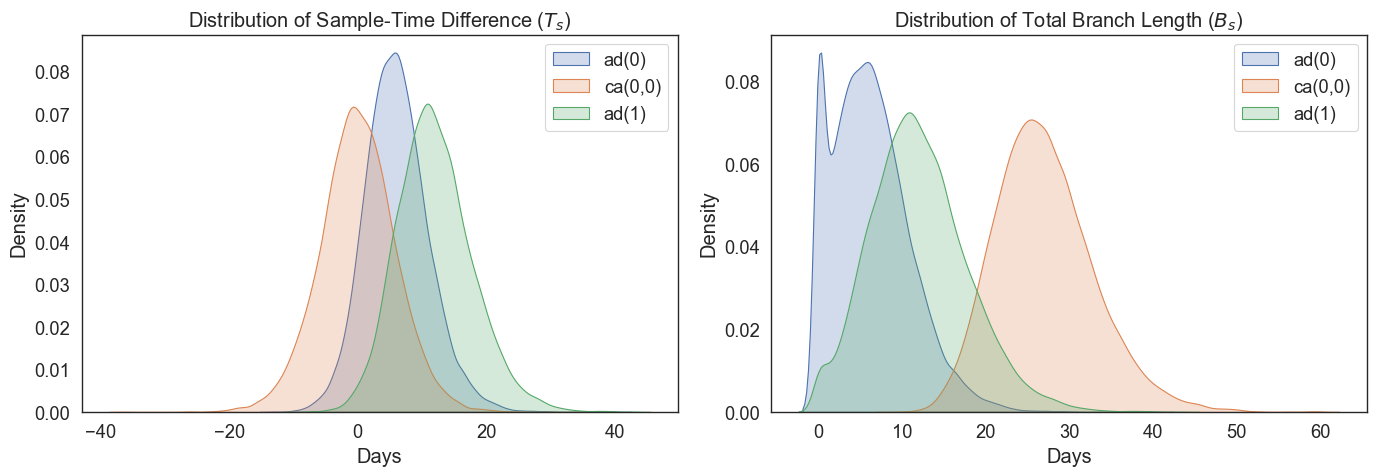

In [4]:
selected_labels = ["ad(0)", "ca(0,0)", "ad(1)",]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label in selected_labels:
    draws = model.draws_by_scenario[label]
    
    # 1. Temporal Distance (T_s)
    sns.kdeplot(draws["time_draws"], ax=axes[0], label=label, fill=True)
    
    # 2. Branch Length (B_s)
    sns.kdeplot(draws["branch_draws"], ax=axes[1], label=label, fill=True)

axes[0].set_title("Distribution of Sample-Time Difference ($T_s$)")
axes[0].set_xlabel("Days")
axes[0].legend()

axes[1].set_title("Distribution of Total Branch Length ($B_s$)")
axes[1].set_xlabel("Days")
axes[1].legend()

plt.tight_layout()
plt.show()

### Joint Distribution of Time and Genetic Distance

The compatibility score for a pair is the product of temporal and genetic compatibilities. We can visualize the joint distribution for a specific scenario (e.g., direct transmission `ad(0)`).

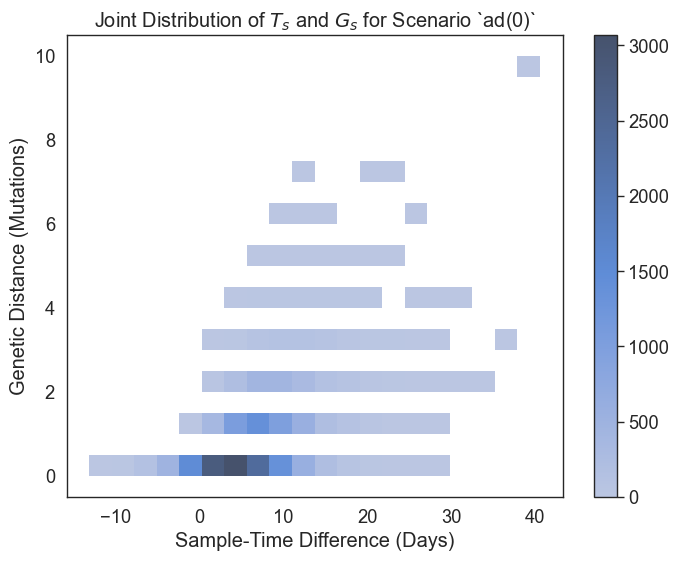

In [5]:
draws_ad0 = model.draws_by_scenario["ad(0)"]

plt.figure(figsize=(8, 6))
sns.histplot(
    x=draws_ad0["time_draws"], 
    y=draws_ad0["genetic_draws"], 
    bins=20, 
    cbar=True
)
plt.title("Joint Distribution of $T_s$ and $G_s$ for Scenario `ad(0)`")
plt.xlabel("Sample-Time Difference (Days)")
plt.ylabel("Genetic Distance (Mutations)")
plt.show()

## 4. Scoring a Single Pair

`score_pair` provides a detailed breakdown of all scenarios for one observation.

In [6]:
result = model.score_pair(
    sample_time_difference=2, # days
    genetic_distance=1.0       # mutations
)

print(f"Target labels: {result.target_labels}")
print(f"Combined Target Compatibility: {result.target_compatibility:.3f}")

# Per-scenario compatibility
print("\nPer-scenario compatibilities:")
for label, score in result.scenario_scores.items():
    print(f"  {label:8} : {score.compatibility:.4f}")

Target labels: ('ad(0)', 'ca(0,0)')
Combined Target Compatibility: 0.636

Per-scenario compatibilities:
  ad(0)    : 0.1013
  ad(1)    : 0.0334
  ad(2)    : 0.0052
  ca(0,0)  : 0.5342
  ca(0,1)  : 0.2991
  ca(0,2)  : 0.0691
  ca(1,0)  : 0.1166
  ca(1,1)  : 0.3173
  ca(2,0)  : 0.0205


## 5. Vectorized Scoring

For large datasets, use `score_target` or `pairwise_model`. They support NumPy broadcasting.

In [7]:
time_diffs = np.array([1.0, 3.0, 5.0])
genetic_dists = np.array([0, 2, 4])

scores = model.score_target(time_diffs, genetic_dists)
print(f"Scores: {scores}")

# Or evaluate on a grid
t_grid, g_grid = np.meshgrid(
    np.linspace(0, 10, 5),
    np.arange(0, 6, 2)
)
grid_scores = model.score_target(t_grid, g_grid)
print(f"\nGrid scores shape: {grid_scores.shape}")

Scores: [0.44857442 0.50599765 0.09095224]

Grid scores shape: (3, 5)


## 6. Simulation Engine

EpiLink includes helpers to simulate outbreak data on a transmission tree.

In [8]:
# Create a simple transmission tree
tree = nx.DiGraph([
    ("case-0", "case-1"),
    ("case-1", "case-2"),
    ("case-0", "case-3")
])

# 1. Simulate sampling dates
dated_tree = simulate_epidemic_dates(profile, tree, fraction_sampled=1.0)

# 2. Simulate genomic sequences
simulated = simulate_genomic_sequences(profile, dated_tree, genome_length=1000)

# 3. Build pairwise table for all pairs
pair_table = build_pairwise_case_table(simulated.packed, dated_tree)

print("Sampled Pair Table:")
display(pair_table.head())

Sampled Pair Table:


,CaseA,CaseB,IsRelated,BothSampled,DeterministicDistance,StochasticDistance,SamplingDateDistanceDays
0,case-0,case-1,True,True,1,1,14.0
1,case-0,case-2,False,True,1,1,17.0
2,case-0,case-3,True,True,1,3,5.0
3,case-1,case-2,True,True,0,0,3.0
4,case-1,case-3,True,True,2,4,10.0


## 7. Score Simulated Pairs

We can now apply the model to our synthetic dataset.

In [9]:
pair_table["epilink_score"] = model.score_target(
    sample_time_difference=pair_table["SamplingDateDistanceDays"],
    genetic_distance=pair_table["StochasticDistance"]
)

display(pair_table[["CaseA", "CaseB", "IsRelated", "epilink_score"]])

,CaseA,CaseB,IsRelated,epilink_score
0,case-0,case-1,True,0.046680
1,case-0,case-2,False,0.017002
2,case-0,case-3,True,0.182229
3,case-1,case-2,True,0.563347
4,case-1,case-3,True,0.022367
5,case-2,case-3,False,0.008325


## 8. Visualizing Score Distribution

Finally, we can visualize how the scores separate related pairs from unrelated ones.

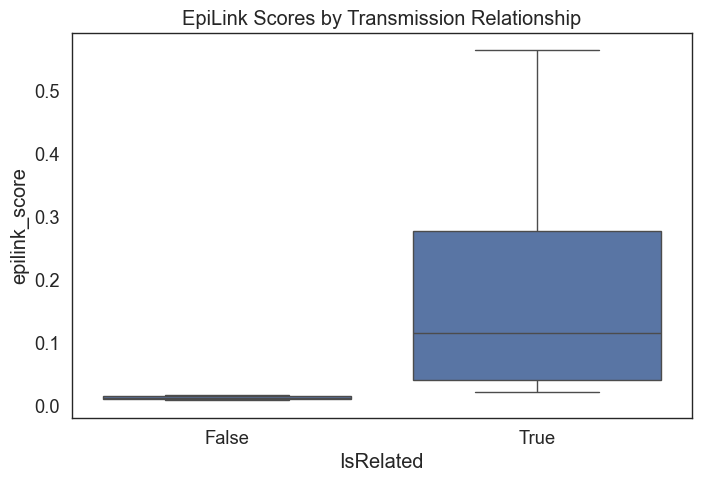

In [10]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=pair_table, x="IsRelated", y="epilink_score")
plt.title("EpiLink Scores by Transmission Relationship")
plt.show()

## 9. CLI Usage

You can also run EpiLink from the command line. If you have a CSV file with the required columns, run:

```bash
epilink input.csv --output results.csv --mc-samples 10000 --target "ad(0)" "ca(0,0)"
```

Use `epilink --help` to see all configuration options for natural history parameters and mutation models.